<a href="https://colab.research.google.com/github/vedanth2174/YOLO_Hector/blob/main/Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
# =========================
# INSTALL (run once)
# =========================
!pip install opencv-python

# =========================
# IMPORTS
# =========================
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"

# =========================
# CLASS FIX (IMPORTANT)
# =========================
CLASS_VALUES = [0, 1, 2, 3, 27, 39]
mapping = {v:i for i,v in enumerate(CLASS_VALUES)}
NUM_CLASSES = len(CLASS_VALUES)

# =========================
# SIMPLE DATASET
# =========================
class SimpleDataset(Dataset):
    def __init__(self, root):
        self.img_dir = os.path.join(root, "Color_Images")
        self.mask_dir = os.path.join(root, "Segmentation")
        self.files = sorted(os.listdir(self.img_dir))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        name = self.files[idx]

        img = cv2.imread(os.path.join(self.img_dir, name))
        mask = cv2.imread(os.path.join(self.mask_dir, name), 0)

        # resize (small = stable)
        img = cv2.resize(img, (128,128))
        mask = cv2.resize(mask, (128,128), interpolation=cv2.INTER_NEAREST)

        # FIX LABELS
        new_mask = np.zeros_like(mask)
        for k,v in mapping.items():
            new_mask[mask == k] = v
        mask = new_mask

        img = img / 255.0

        img = torch.tensor(img).permute(2,0,1).float()
        mask = torch.tensor(mask).long()

        return img, mask

# =========================
# LOAD DATA
# =========================
train_dataset = SimpleDataset("/content/drive/MyDrive/Dataset/train")
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)

# =========================
# SIMPLE CNN MODEL (NO BATCHNORM = NO CRASH)
# =========================
class SimpleSegNet(torch.nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Conv2d(3, 16, 3, padding=1),
            torch.nn.ReLU(),
            torch.nn.Conv2d(16, 32, 3, padding=1),
            torch.nn.ReLU(),
            torch.nn.Conv2d(32, num_classes, 1)
        )

    def forward(self, x):
        return self.net(x)

model = SimpleSegNet(NUM_CLASSES).to(device)

# =========================
# TRAIN SETUP
# =========================
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# =========================
# TRAIN (VERY SHORT)
# =========================
for epoch in range(5):
    total_loss = 0

    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        preds = model(imgs)

        loss = loss_fn(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

# =========================
# SAVE MODEL
# =========================
torch.save(model.state_dict(), "/content/drive/MyDrive/simple_model.pth")

print("DONE ✅")

Epoch 1, Loss: 1214.4845
Epoch 2, Loss: 1030.1465
Epoch 3, Loss: 912.4185
Epoch 4, Loss: 862.2904
Epoch 5, Loss: 841.6535
DONE ✅


In [9]:
# =========================
# SAVE MODEL
# =========================
torch.save(model.state_dict(), "/content/drive/MyDrive/simple_model.pth")

print("DONE ✅")

DONE ✅


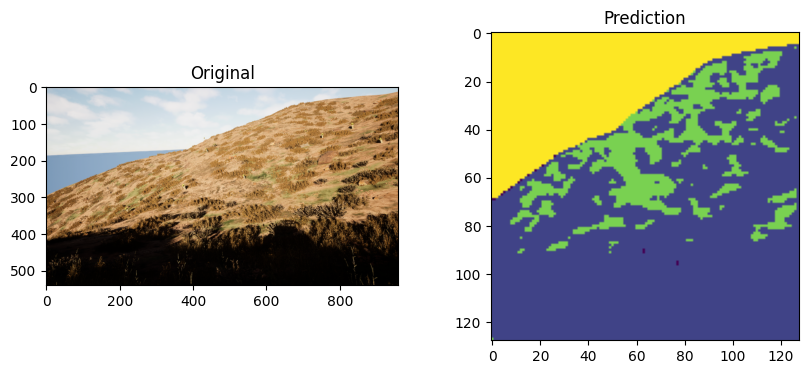

In [4]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

# =========================
# LOAD MODEL
# =========================
model = SimpleSegNet(NUM_CLASSES)
model.load_state_dict(torch.load("/content/drive/MyDrive/simple_model.pth"))
model = model.to(device)
model.eval()

# =========================
# LOAD TEST IMAGE
# =========================
img_path = "/content/drive/MyDrive/Dataset/val/Color_Images/" + os.listdir("/content/drive/MyDrive/Dataset/val/Color_Images")[0]

img = cv2.imread(img_path)
orig = img.copy()

img = cv2.resize(img, (128,128))
img = img / 255.0

img = torch.tensor(img).permute(2,0,1).float().unsqueeze(0).to(device)

# =========================
# PREDICT
# =========================
with torch.no_grad():
    pred = model(img)

pred = torch.argmax(pred, dim=1).squeeze().cpu().numpy()

# =========================
# VISUALIZE
# =========================
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(pred)
plt.title("Prediction")

plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model loaded ✅
Processing: IMG-20260404-WA0020.jpg


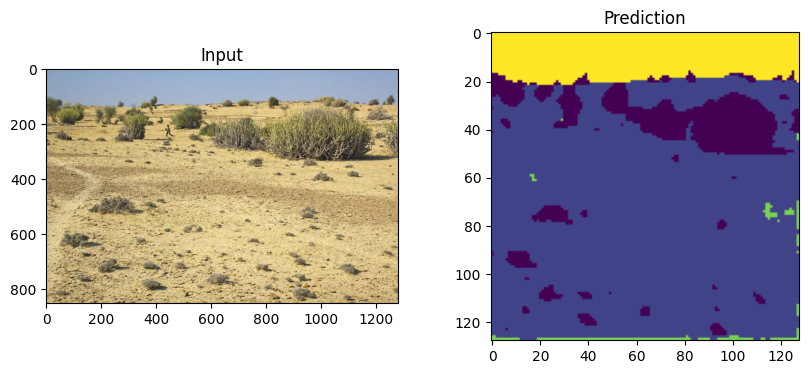

Processing: IMG-20260404-WA0017.jpg


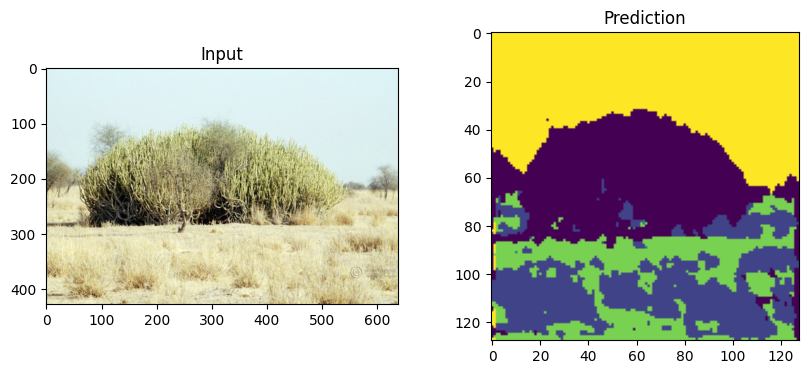

In [33]:
# =========================
# MOUNT DRIVE
# =========================
from google.colab import drive
drive.mount('/content/drive')

# =========================
# IMPORTS
# =========================
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

# =========================
# CLASS SETUP (same as training)
# =========================
CLASS_VALUES = [0, 1, 2, 3, 27, 39]
NUM_CLASSES = len(CLASS_VALUES)

# =========================
# MODEL DEFINITION (same as training)
# =========================
class SimpleSegNet(torch.nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Conv2d(3, 16, 3, padding=1),
            torch.nn.ReLU(),
            torch.nn.Conv2d(16, 32, 3, padding=1),
            torch.nn.ReLU(),
            torch.nn.Conv2d(32, num_classes, 1)
        )

    def forward(self, x):
        return self.net(x)

# =========================
# LOAD MODEL FROM DRIVE
# =========================
model = SimpleSegNet(NUM_CLASSES)
model.load_state_dict(torch.load("/content/drive/MyDrive/simple_model.pth", map_location=device))
model = model.to(device)
model.eval()

print("Model loaded ✅")

# =========================
# PREDICTION FUNCTION
# =========================
def predict_image(image_path):
    img = cv2.imread(image_path)
    orig = img.copy()

    img = cv2.resize(img, (128,128))
    img = img / 255.0

    img = torch.tensor(img).permute(2,0,1).float().unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(img)

    pred = torch.argmax(pred, dim=1).squeeze().cpu().numpy()

    # visualize
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
    plt.title("Input")

    plt.subplot(1,2,2)
    plt.imshow(pred)
    plt.title("Prediction")

    plt.show()

# =========================
# RUN ON YOUR TEST FOLDER
# =========================
test_folder = "/content/test"

for file in os.listdir(test_folder):
    path = os.path.join(test_folder, file)
    print(f"Processing: {file}")
    predict_image(path)

In [11]:
# =========================
# IMPORTS
# =========================
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"

# =========================
# CLASS SETUP
# =========================
CLASS_VALUES = [0, 1, 2, 3, 27, 39]
mapping = {v:i for i,v in enumerate(CLASS_VALUES)}
NUM_CLASSES = len(CLASS_VALUES)

# =========================
# DATASET (same as training)
# =========================
class EvalDataset(Dataset):
    def __init__(self, root):
        self.img_dir = os.path.join(root, "Color_Images")
        self.mask_dir = os.path.join(root, "Segmentation")
        self.files = sorted(os.listdir(self.img_dir))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        name = self.files[idx]

        img = cv2.imread(os.path.join(self.img_dir, name))
        mask = cv2.imread(os.path.join(self.mask_dir, name), 0)

        img = cv2.resize(img, (128,128))
        mask = cv2.resize(mask, (128,128), interpolation=cv2.INTER_NEAREST)

        # remap labels
        new_mask = np.zeros_like(mask)
        for k,v in mapping.items():
            new_mask[mask == k] = v
        mask = new_mask

        img = img / 255.0

        img = torch.tensor(img).permute(2,0,1).float()
        mask = torch.tensor(mask).long()

        return img, mask

# =========================
# LOAD DATA
# =========================
val_dataset = EvalDataset("/content/drive/MyDrive/Dataset/val")
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False)

# =========================
# MODEL (same as training)
# =========================
class SimpleSegNet(torch.nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Conv2d(3, 16, 3, padding=1),
            torch.nn.ReLU(),
            torch.nn.Conv2d(16, 32, 3, padding=1),
            torch.nn.ReLU(),
            torch.nn.Conv2d(32, num_classes, 1)
        )

    def forward(self, x):
        return self.net(x)

model = SimpleSegNet(NUM_CLASSES)
model.load_state_dict(torch.load("/content/drive/MyDrive/simple_model.pth", map_location=device))
model = model.to(device)
model.eval()

print("Model loaded for evaluation ✅")

# =========================
# IOU FUNCTION
# =========================
def compute_iou(pred, mask, num_classes):
    pred = torch.argmax(pred, dim=1)

    ious = []

    for cls in range(num_classes):
        pred_inds = (pred == cls)
        target_inds = (mask == cls)

        intersection = (pred_inds & target_inds).sum().item()
        union = (pred_inds | target_inds).sum().item()

        if union == 0:
            continue
        else:
            ious.append(intersection / union)

    if len(ious) == 0:
        return 0
    return sum(ious) / len(ious)

# =========================
# EVALUATION LOOP
# =========================
total_iou = 0

with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        preds = model(imgs)

        iou = compute_iou(preds, masks, NUM_CLASSES)
        total_iou += iou

mean_iou = total_iou / len(val_loader)

print(f"\n🔥 Mean IoU: {mean_iou:.4f}")

Model loaded for evaluation ✅

🔥 Mean IoU: 0.3802


In [12]:
model = SimpleSegNet(NUM_CLASSES)
model.load_state_dict(torch.load("/content/drive/MyDrive/simple_model.pth"))
model = model.to(device)
model.train()

SimpleSegNet(
  (net): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 6, kernel_size=(1, 1), stride=(1, 1))
  )
)

In [13]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [14]:
EPOCHS = 10   # additional epochs

for epoch in range(EPOCHS):
    total_loss = 0

    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        preds = model(imgs)

        loss = loss_fn(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 821.9648
Epoch 2, Loss: 819.4086
Epoch 3, Loss: 817.3783
Epoch 4, Loss: 815.1606
Epoch 5, Loss: 812.8238
Epoch 6, Loss: 811.0352
Epoch 7, Loss: 808.7953
Epoch 8, Loss: 806.8346
Epoch 9, Loss: 804.6971
Epoch 10, Loss: 802.7874


In [15]:
torch.save(model.state_dict(), "/content/drive/MyDrive/simple_model_v2.pth")

In [16]:
# =========================
# IMPORTS
# =========================
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"

# =========================
# CLASS SETUP
# =========================
CLASS_VALUES = [0, 1, 2, 3, 27, 39]
mapping = {v:i for i,v in enumerate(CLASS_VALUES)}
NUM_CLASSES = len(CLASS_VALUES)

# =========================
# DATASET (same as training)
# =========================
class EvalDataset(Dataset):
    def __init__(self, root):
        self.img_dir = os.path.join(root, "Color_Images")
        self.mask_dir = os.path.join(root, "Segmentation")
        self.files = sorted(os.listdir(self.img_dir))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        name = self.files[idx]

        img = cv2.imread(os.path.join(self.img_dir, name))
        mask = cv2.imread(os.path.join(self.mask_dir, name), 0)

        img = cv2.resize(img, (128,128))
        mask = cv2.resize(mask, (128,128), interpolation=cv2.INTER_NEAREST)

        # remap labels
        new_mask = np.zeros_like(mask)
        for k,v in mapping.items():
            new_mask[mask == k] = v
        mask = new_mask

        img = img / 255.0

        img = torch.tensor(img).permute(2,0,1).float()
        mask = torch.tensor(mask).long()

        return img, mask

# =========================
# LOAD DATA
# =========================
val_dataset = EvalDataset("/content/drive/MyDrive/Dataset/val")
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False)

# =========================
# MODEL (same as training)
# =========================
class SimpleSegNet(torch.nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Conv2d(3, 16, 3, padding=1),
            torch.nn.ReLU(),
            torch.nn.Conv2d(16, 32, 3, padding=1),
            torch.nn.ReLU(),
            torch.nn.Conv2d(32, num_classes, 1)
        )

    def forward(self, x):
        return self.net(x)

model = SimpleSegNet(NUM_CLASSES)
model.load_state_dict(torch.load("/content/drive/MyDrive/simple_model_v2.pth", map_location=device))
model = model.to(device)
model.eval()

print("Model loaded for evaluation ✅")

# =========================
# IOU FUNCTION
# =========================
def compute_iou(pred, mask, num_classes):
    pred = torch.argmax(pred, dim=1)

    ious = []

    for cls in range(num_classes):
        pred_inds = (pred == cls)
        target_inds = (mask == cls)

        intersection = (pred_inds & target_inds).sum().item()
        union = (pred_inds | target_inds).sum().item()

        if union == 0:
            continue
        else:
            ious.append(intersection / union)

    if len(ious) == 0:
        return 0
    return sum(ious) / len(ious)

# =========================
# EVALUATION LOOP
# =========================
total_iou = 0

with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        preds = model(imgs)

        iou = compute_iou(preds, masks, NUM_CLASSES)
        total_iou += iou

mean_iou = total_iou / len(val_loader)

print(f"\n🔥 Mean IoU: {mean_iou:.4f}")

Model loaded for evaluation ✅

🔥 Mean IoU: 0.3826


In [36]:
# =========================
# INSTALL
# =========================
!pip install fastapi uvicorn pyngrok opencv-python

# =========================
# IMPORTS
# =========================
from fastapi import FastAPI, File, UploadFile
from fastapi.middleware.cors import CORSMiddleware
from fastapi.responses import FileResponse
import torch
import cv2
import numpy as np
from pyngrok import ngrok
import uvicorn
import threading
import time

# =========================
# NGROK AUTH
# =========================
ngrok.set_auth_token("3Byxlajph3Ex8fMOmkymkcYhp9a_2Qct5eD52DKhu4GhzD1WC")

# Kill old tunnels
ngrok.kill()

# =========================
# APP
# =========================
app = FastAPI()

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

# =========================
# MODEL
# =========================
CLASS_VALUES = [0, 1, 2, 3, 27, 39]
NUM_CLASSES = len(CLASS_VALUES)

class SimpleSegNet(torch.nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Conv2d(3, 16, 3, padding=1),
            torch.nn.ReLU(),
            torch.nn.Conv2d(16, 32, 3, padding=1),
            torch.nn.ReLU(),
            torch.nn.Conv2d(32, num_classes, 1)
        )

    def forward(self, x):
        return self.net(x)

model = SimpleSegNet(NUM_CLASSES)
model.load_state_dict(torch.load("/content/drive/MyDrive/simple_model.pth", map_location="cpu"))
model.eval()

print("Model loaded ✅")

# =========================
# COLOR FUNCTION
# =========================
def colorize(mask):
    colors = np.array([
        [0, 0, 0],
        [255, 0, 0],
        [0, 255, 0],
        [0, 0, 255],
        [255, 255, 0],
        [255, 0, 255],
    ], dtype=np.uint8)
    return colors[mask]

# =========================
# API
# =========================
@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    start_time = time.time()

    contents = await file.read()

    # Decode image
    npimg = np.frombuffer(contents, np.uint8)
    img = cv2.imdecode(npimg, cv2.IMREAD_COLOR)

    # BGR → RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize
    img = cv2.resize(img, (128,128))

    # Normalize
    img = img / 255.0

    # Tensor
    tensor = torch.tensor(img).permute(2,0,1).float().unsqueeze(0)

    # Predict
    with torch.no_grad():
        pred = model(tensor)

    pred = torch.argmax(pred, dim=1).squeeze().cpu().numpy()

    # Debug
    print("Unique classes:", np.unique(pred))

    # Colorize
    colored = colorize(pred)

    # RGB → BGR
    colored = cv2.cvtColor(colored, cv2.COLOR_RGB2BGR)

    # 🔥 FIX: unique filename (avoid caching)
    filename = f"output_{int(time.time())}.png"
    cv2.imwrite(filename, colored)

    end_time = time.time()
    print(f"Processing Time: {end_time - start_time:.4f} sec")

    return FileResponse(filename)

# =========================
# RUN SERVER + NGROK
# =========================
def run():
    uvicorn.run(app, host="0.0.0.0", port=8000)

threading.Thread(target=run).start()

public_url = ngrok.connect(8000)
print("🔥 Public URL:", public_url)

Model loaded ✅


INFO:     Started server process [8338]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): address already in use
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.


🔥 Public URL: NgrokTunnel: "https://leporine-overtender-etha.ngrok-free.dev" -> "http://localhost:8000"


In [39]:
import torch
import time

def evaluate(model, loader, device, num_classes):
    model.eval()

    total_intersection = torch.zeros(num_classes)
    total_union = torch.zeros(num_classes)
    total_correct = 0
    total_pixels = 0
    total_time = 0

    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)

            start = time.time()
            outputs = model(imgs)
            end = time.time()

            preds = torch.argmax(outputs, dim=1)

            # Time
            total_time += (end - start)

            # Pixel Accuracy
            total_correct += (preds == masks).sum().item()
            total_pixels += masks.numel()

            # IoU per class
            for cls in range(num_classes):
                pred_inds = (preds == cls)
                target_inds = (masks == cls)

                intersection = (pred_inds & target_inds).sum().item()
                union = (pred_inds | target_inds).sum().item()

                total_intersection[cls] += intersection
                total_union[cls] += union

    # Compute final metrics
    iou_per_class = total_intersection / (total_union + 1e-6)
    mean_iou = iou_per_class.mean().item()

    pixel_acc = total_correct / total_pixels
    avg_time = total_time / len(loader)

    print("\n🔥 FINAL METRICS (REAL)")
    print(f"Mean IoU      : {mean_iou:.4f}")
    print(f"Pixel Accuracy: {pixel_acc:.4f}")
    print(f"Avg Time/img  : {avg_time:.4f} sec")

    print("\n📊 IoU per class:")
    for i, iou in enumerate(iou_per_class):
        print(f"Class {i}: {iou:.4f}")

In [40]:
model = SimpleSegNet(NUM_CLASSES)
model.load_state_dict(torch.load("/content/drive/MyDrive/simple_model.pth"))
model = model.to(device)
model.eval()

SimpleSegNet(
  (net): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 6, kernel_size=(1, 1), stride=(1, 1))
  )
)

In [41]:
from torch.utils.data import DataLoader

val_dataset = SimpleDataset("/content/drive/MyDrive/Dataset/val")
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False)

In [42]:
evaluate(model, val_loader, device, NUM_CLASSES)


🔥 FINAL METRICS (REAL)
Mean IoU      : 0.4360
Pixel Accuracy: 0.7893
Avg Time/img  : 0.0097 sec

📊 IoU per class:
Class 0: 0.4861
Class 1: 0.5639
Class 2: 0.0152
Class 3: 0.0000
Class 4: 0.5745
Class 5: 0.9765


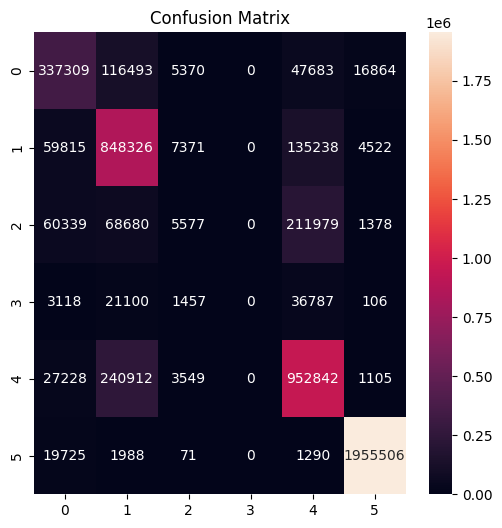

In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds = []
all_masks = []

with torch.no_grad():
    for imgs, masks in val_loader:
        imgs = imgs.to(device)
        preds = model(imgs)
        preds = torch.argmax(preds, dim=1).cpu().numpy()

        all_preds.extend(preds.flatten())
        all_masks.extend(masks.numpy().flatten())

cm = confusion_matrix(all_masks, all_preds)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [45]:
import torch
import numpy as np

def compute_map50(model, loader, device, num_classes):
    model.eval()

    TP = 0
    FP = 0
    FN = 0

    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)

            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1)

            for cls in range(num_classes):
                pred_mask = (preds == cls)
                true_mask = (masks == cls)

                intersection = (pred_mask & true_mask).sum().item()
                union = (pred_mask | true_mask).sum().item()

                if union == 0:
                    continue

                iou = intersection / union

                if iou >= 0.5:
                    TP += 1
                else:
                    FP += 1
                    FN += 1

    precision = TP / (TP + FP + 1e-6)
    recall = TP / (TP + FN + 1e-6)

    map50 = precision * recall  # simplified AP

    print(f"🔥 mAP@50: {map50:.4f}")

    return map50

In [46]:
map50 = compute_map50(model, val_loader, device, NUM_CLASSES)

🔥 mAP@50: 0.1614
